# Customer Churn Analysis
## Task 03 — Business KPI Dashboard

### Objective

The objective of this task is to transform the cleaned customer churn
dataset into business-focused Key Performance Indicators (KPIs) and
visualizations.

The dashboard will help decision-makers understand:

- Overall customer churn
- Customer retention
- Revenue at risk
- Churn across contract types
- Churn across tenure groups
- Churn across payment methods
- Customer-level business risk

### Key Business Question

Which customer groups contribute most to churn and potential revenue loss,
and where should the business prioritize retention efforts?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

In [2]:
from google.colab import files

uploaded = files.upload()

Saving customer_churn_cleaned.csv to customer_churn_cleaned.csv


In [3]:
df = pd.read_csv("customer_churn_cleaned.csv")

df

,CustomerID,Gender,Age,TenureMonths,SubscriptionType,MonthlyCharges,TotalCharges,ContractType,SupportTickets,PaymentMethod,Churn,TenureGroup
0,CUST-1001,Female,34,12,Basic,49.99,599.88,Month-to-Month,3,Credit Card,Yes,0-12 months
1,CUST-1002,Male,45,24,Pro,79.99,1919.76,One Year,1,Bank Transfer,No,13-24 months
2,CUST-1003,Female,29,6,Basic,49.99,299.94,Month-to-Month,5,UPI,Yes,0-12 months
3,CUST-1004,Male,52,36,Enterprise,149.99,5399.64,Two Year,0,Credit Card,No,25-36 months
4,CUST-1005,Female,41,8,Pro,79.99,639.92,Month-to-Month,4,Debit Card,Yes,0-12 months
5,CUST-1006,Male,31,18,Basic,49.99,899.82,One Year,2,UPI,No,13-24 months
6,CUST-1007,Female,23,3,Basic,49.99,149.97,Month-to-Month,6,Credit Card,Yes,0-12 months
7,CUST-1008,Male,60,48,Enterprise,149.99,7199.52,Two Year,1,Bank Transfer,No,37+ months
8,CUST-1009,Female,38,15,Pro,79.99,1199.85,One Year,2,Credit Card,No,13-24 months
9,CUST-1010,Male,27,4,Basic,49.99,199.96,Month-to-Month,4,UPI,Yes,0-12 months


In [4]:
df.head()

,CustomerID,Gender,Age,TenureMonths,SubscriptionType,MonthlyCharges,TotalCharges,ContractType,SupportTickets,PaymentMethod,Churn,TenureGroup
0,CUST-1001,Female,34,12,Basic,49.99,599.88,Month-to-Month,3,Credit Card,Yes,0-12 months
1,CUST-1002,Male,45,24,Pro,79.99,1919.76,One Year,1,Bank Transfer,No,13-24 months
2,CUST-1003,Female,29,6,Basic,49.99,299.94,Month-to-Month,5,UPI,Yes,0-12 months
3,CUST-1004,Male,52,36,Enterprise,149.99,5399.64,Two Year,0,Credit Card,No,25-36 months
4,CUST-1005,Female,41,8,Pro,79.99,639.92,Month-to-Month,4,Debit Card,Yes,0-12 months


In [5]:
df.tail()

,CustomerID,Gender,Age,TenureMonths,SubscriptionType,MonthlyCharges,TotalCharges,ContractType,SupportTickets,PaymentMethod,Churn,TenureGroup
10,CUST-1011,Female,49,30,Enterprise,149.99,4499.70,Two Year,0,Credit Card,No,25-36 months
11,CUST-1012,Male,33,14,Pro,79.99,1119.86,Month-to-Month,3,Debit Card,Yes,13-24 months
12,CUST-1013,Female,55,22,Basic,49.99,1099.78,One Year,1,Bank Transfer,No,13-24 months
13,CUST-1014,Male,26,2,Basic,49.99,99.98,Month-to-Month,5,UPI,Yes,0-12 months
14,CUST-1015,Female,43,40,Enterprise,149.99,5999.60,Two Year,1,Credit Card,No,37+ months


In [18]:
print("Number of customers:", len(df))
print("Number of columns:", len(df.columns))

print("\nTotal missing values:",
      df.isnull().sum().sum())

print("Duplicate rows:",
      df.duplicated().sum())

Number of customers: 15
Number of columns: 12

Total missing values: 0
Duplicate rows: 0


In [20]:
df["TenureGroup"] = pd.cut(
    df["TenureMonths"],
    bins=[-1, 12, 24, 36, 100],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-36 months",
        "37+ months"
    ]
)

df[["CustomerID", "TenureMonths", "TenureGroup"]]

,CustomerID,TenureMonths,TenureGroup
0,CUST-1001,12,0-12 months
1,CUST-1002,24,13-24 months
2,CUST-1003,6,0-12 months
3,CUST-1004,36,25-36 months
4,CUST-1005,8,0-12 months
5,CUST-1006,18,13-24 months
6,CUST-1007,3,0-12 months
7,CUST-1008,48,37+ months
8,CUST-1009,15,13-24 months
9,CUST-1010,4,0-12 months


In [21]:
df[["CustomerID", "TenureMonths", "TenureGroup"]].head()

,CustomerID,TenureMonths,TenureGroup
0,CUST-1001,12,0-12 months
1,CUST-1002,24,13-24 months
2,CUST-1003,6,0-12 months
3,CUST-1004,36,25-36 months
4,CUST-1005,8,0-12 months


In [22]:
df[["CustomerID", "TenureMonths", "TenureGroup"]].tail()

,CustomerID,TenureMonths,TenureGroup
10,CUST-1011,30,25-36 months
11,CUST-1012,14,13-24 months
12,CUST-1013,22,13-24 months
13,CUST-1014,2,0-12 months
14,CUST-1015,40,37+ months


In [23]:
# Total customers
total_customers = len(df)

# Churned customers
churned_customers = (df["Churn"] == "Yes").sum()

# Retained customers
retained_customers = (df["Churn"] == "No").sum()

# Churn rate
churn_rate = (
    churned_customers / total_customers
) * 100

# Retention rate
retention_rate = (
    retained_customers / total_customers
) * 100

# Total monthly revenue
total_monthly_revenue = df["MonthlyCharges"].sum()

# Revenue at risk
revenue_at_risk = df.loc[
    df["Churn"] == "Yes",
    "MonthlyCharges"
].sum()

# Revenue at risk percentage
revenue_at_risk_percentage = (
    revenue_at_risk / total_monthly_revenue
) * 100

In [24]:
print("=" * 50)
print("CUSTOMER CHURN KPI SUMMARY")
print("=" * 50)

print(f"Total Customers       : {total_customers}")
print(f"Churned Customers     : {churned_customers}")
print(f"Retained Customers    : {retained_customers}")
print(f"Churn Rate            : {churn_rate:.2f}%")
print(f"Retention Rate        : {retention_rate:.2f}%")
print(f"Total Monthly Revenue : {total_monthly_revenue:,.2f}")
print(f"Revenue at Risk       : {revenue_at_risk:,.2f}")
print(f"Revenue at Risk (%)   : {revenue_at_risk_percentage:.2f}%")

CUSTOMER CHURN KPI SUMMARY
Total Customers       : 15
Churned Customers     : 7
Retained Customers    : 8
Churn Rate            : 46.67%
Retention Rate        : 53.33%
Total Monthly Revenue : 1,269.85
Revenue at Risk       : 409.93
Revenue at Risk (%)   : 32.28%


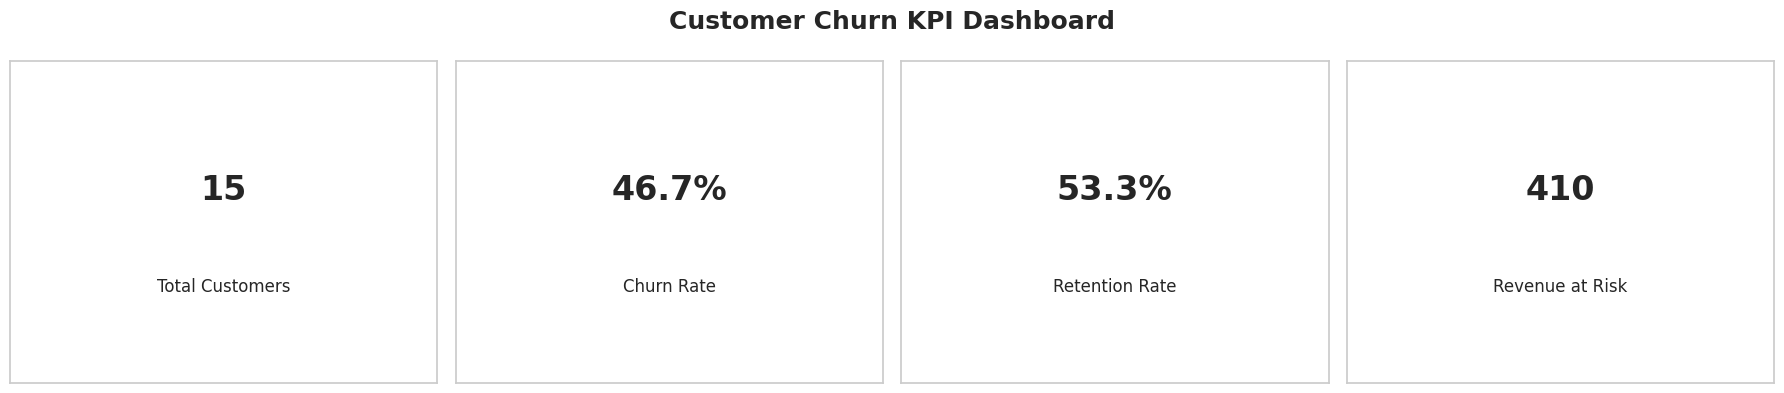

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

kpis = [
    ("Total Customers", f"{total_customers}"),
    ("Churn Rate", f"{churn_rate:.1f}%"),
    ("Retention Rate", f"{retention_rate:.1f}%"),
    ("Revenue at Risk", f"{revenue_at_risk:,.0f}")
]

for ax, (title, value) in zip(axes, kpis):
    ax.text(
        0.5, 0.60,
        value,
        ha="center",
        va="center",
        fontsize=24,
        fontweight="bold"
    )

    ax.text(
        0.5, 0.30,
        title,
        ha="center",
        va="center",
        fontsize=12
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(True)

plt.suptitle(
    "Customer Churn KPI Dashboard",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

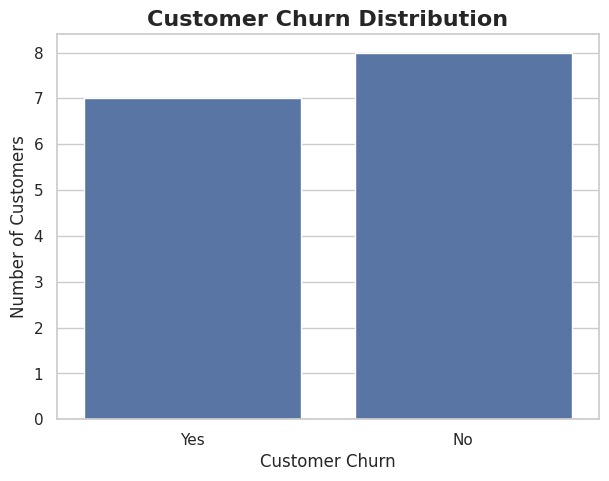

In [26]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title(
    "Customer Churn Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Churn")
plt.ylabel("Number of Customers")

plt.show()

In [28]:
contract_churn = (
    df.groupby("ContractType")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

contract_churn

,ContractType,ChurnRate
0,Month-to-Month,100.0
1,One Year,0.0
2,Two Year,0.0


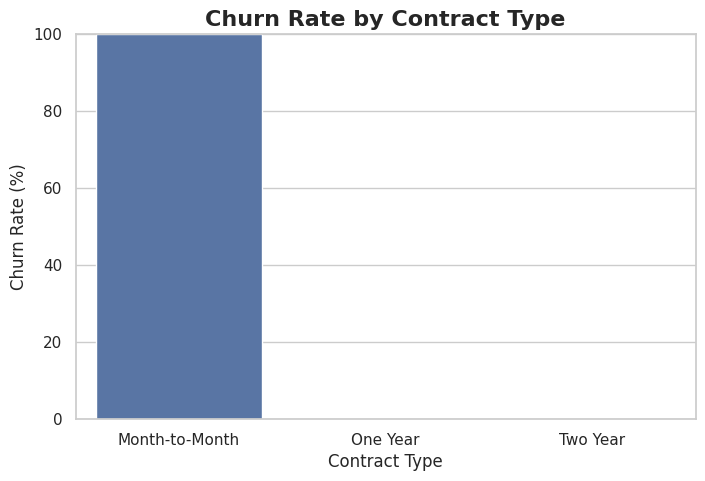

In [30]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=contract_churn,
    x="ContractType",
    y="ChurnRate"
)

plt.title(
    "Churn Rate by Contract Type",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.ylim(0, 100)

plt.show()

In [31]:
tenure_churn = (
    df.groupby(
        "TenureGroup",
        observed=False
    )["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

tenure_churn

,TenureGroup,ChurnRate
0,0-12 months,100.0
1,13-24 months,20.0
2,25-36 months,0.0
3,37+ months,0.0


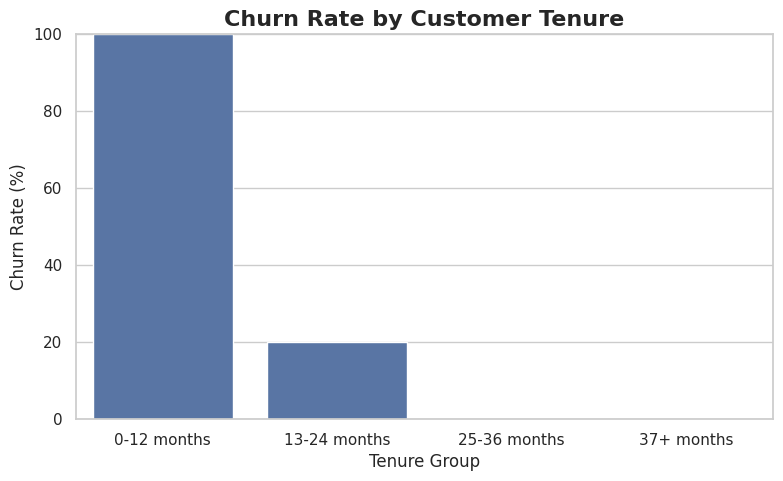

In [43]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=tenure_churn,
    x="TenureGroup",
    y="ChurnRate"
)

plt.title(
    "Churn Rate by Customer Tenure",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.ylim(0, 100)

plt.show()

In [33]:
payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

payment_churn

,PaymentMethod,ChurnRate
0,Bank Transfer,0.000000
1,Credit Card,33.333333
2,Debit Card,100.000000
3,UPI,75.000000


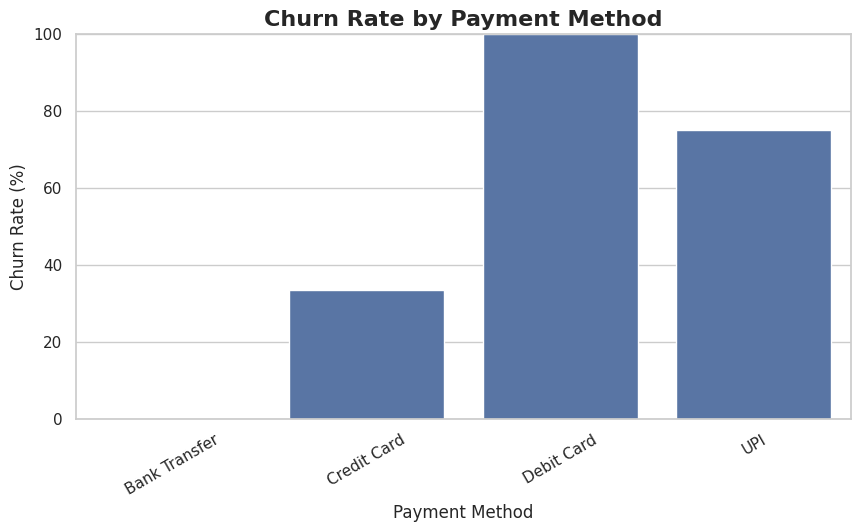

In [34]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=payment_churn,
    x="PaymentMethod",
    y="ChurnRate"
)

plt.title(
    "Churn Rate by Payment Method",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=30)

plt.ylim(0, 100)

plt.show()

In [35]:
subscription_churn = (
    df.groupby("SubscriptionType")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

subscription_churn

,SubscriptionType,ChurnRate
0,Basic,71.428571
1,Enterprise,0.000000
2,Pro,50.000000


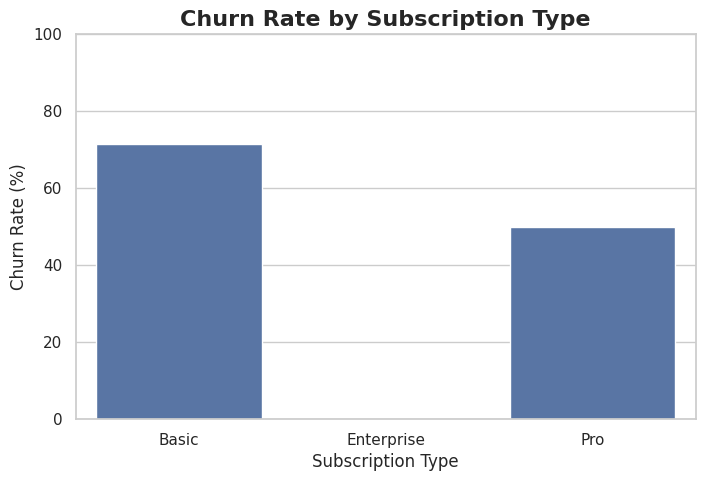

In [36]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=subscription_churn,
    x="SubscriptionType",
    y="ChurnRate"
)

plt.title(
    "Churn Rate by Subscription Type",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Subscription Type")
plt.ylabel("Churn Rate (%)")

plt.ylim(0, 100)

plt.show()

In [37]:
support_churn = (
    df.groupby("SupportTickets")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

support_churn

,SupportTickets,ChurnRate
0,0,0.0
1,1,0.0
2,2,0.0
3,3,100.0
4,4,100.0
5,5,100.0
6,6,100.0


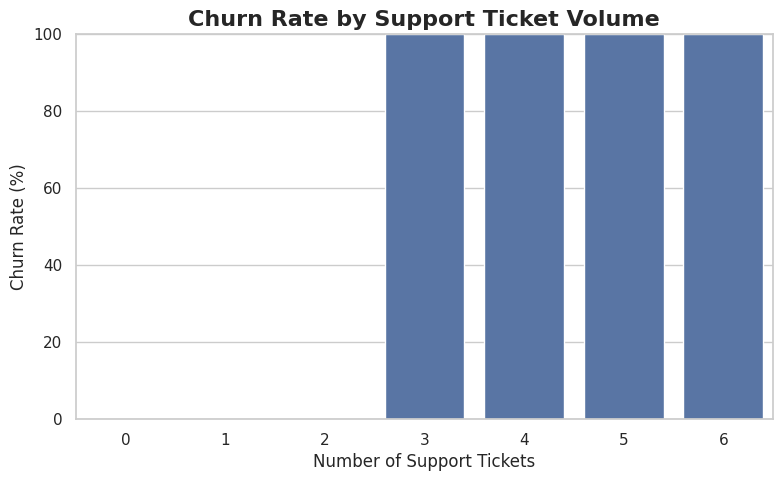

In [38]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=support_churn,
    x="SupportTickets",
    y="ChurnRate"
)

plt.title(
    "Churn Rate by Support Ticket Volume",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Support Tickets")
plt.ylabel("Churn Rate (%)")

plt.ylim(0, 100)

plt.show()

In [40]:
revenue_risk_contract = (
    df[df["Churn"] == "Yes"]
    .groupby("ContractType")["MonthlyCharges"]
    .sum()
    .reset_index(name="RevenueAtRisk")
)

revenue_risk_contract

,ContractType,RevenueAtRisk
0,Month-to-Month,409.93


In [44]:
customer_table = df[[
    "CustomerID",
    "ContractType",
    "TenureMonths",
    "TenureGroup",
    "PaymentMethod",
    "SubscriptionType",
    "MonthlyCharges",
    "SupportTickets",
    "Churn"
]].copy()

customer_table

,CustomerID,ContractType,TenureMonths,TenureGroup,PaymentMethod,SubscriptionType,MonthlyCharges,SupportTickets,Churn
0,CUST-1001,Month-to-Month,12,0-12 months,Credit Card,Basic,49.99,3,Yes
1,CUST-1002,One Year,24,13-24 months,Bank Transfer,Pro,79.99,1,No
2,CUST-1003,Month-to-Month,6,0-12 months,UPI,Basic,49.99,5,Yes
3,CUST-1004,Two Year,36,25-36 months,Credit Card,Enterprise,149.99,0,No
4,CUST-1005,Month-to-Month,8,0-12 months,Debit Card,Pro,79.99,4,Yes
5,CUST-1006,One Year,18,13-24 months,UPI,Basic,49.99,2,No
6,CUST-1007,Month-to-Month,3,0-12 months,Credit Card,Basic,49.99,6,Yes
7,CUST-1008,Two Year,48,37+ months,Bank Transfer,Enterprise,149.99,1,No
8,CUST-1009,One Year,15,13-24 months,Credit Card,Pro,79.99,2,No
9,CUST-1010,Month-to-Month,4,0-12 months,UPI,Basic,49.99,4,Yes


In [45]:
churned_customers_table = df[
    df["Churn"] == "Yes"
][[
    "CustomerID",
    "ContractType",
    "TenureMonths",
    "PaymentMethod",
    "SubscriptionType",
    "MonthlyCharges",
    "SupportTickets",
    "Churn"
]].sort_values(
    by="MonthlyCharges",
    ascending=False
)

churned_customers_table

,CustomerID,ContractType,TenureMonths,PaymentMethod,SubscriptionType,MonthlyCharges,SupportTickets,Churn
4,CUST-1005,Month-to-Month,8,Debit Card,Pro,79.99,4,Yes
11,CUST-1012,Month-to-Month,14,Debit Card,Pro,79.99,3,Yes
0,CUST-1001,Month-to-Month,12,Credit Card,Basic,49.99,3,Yes
2,CUST-1003,Month-to-Month,6,UPI,Basic,49.99,5,Yes
6,CUST-1007,Month-to-Month,3,Credit Card,Basic,49.99,6,Yes
9,CUST-1010,Month-to-Month,4,UPI,Basic,49.99,4,Yes
13,CUST-1014,Month-to-Month,2,UPI,Basic,49.99,5,Yes


In [46]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "Churned Customers",
        "Retained Customers",
        "Churn Rate",
        "Retention Rate",
        "Total Monthly Revenue",
        "Revenue at Risk",
        "Revenue at Risk %"
    ],

    "Value": [
        total_customers,
        churned_customers,
        retained_customers,
        f"{churn_rate:.2f}%",
        f"{retention_rate:.2f}%",
        f"{total_monthly_revenue:,.2f}",
        f"{revenue_at_risk:,.2f}",
        f"{revenue_at_risk_percentage:.2f}%"
    ]
})

kpi_summary

,KPI,Value
0,Total Customers,15
1,Churned Customers,7
2,Retained Customers,8
3,Churn Rate,46.67%
4,Retention Rate,53.33%
5,Total Monthly Revenue,"1,269.85"
6,Revenue at Risk,409.93
7,Revenue at Risk %,32.28%


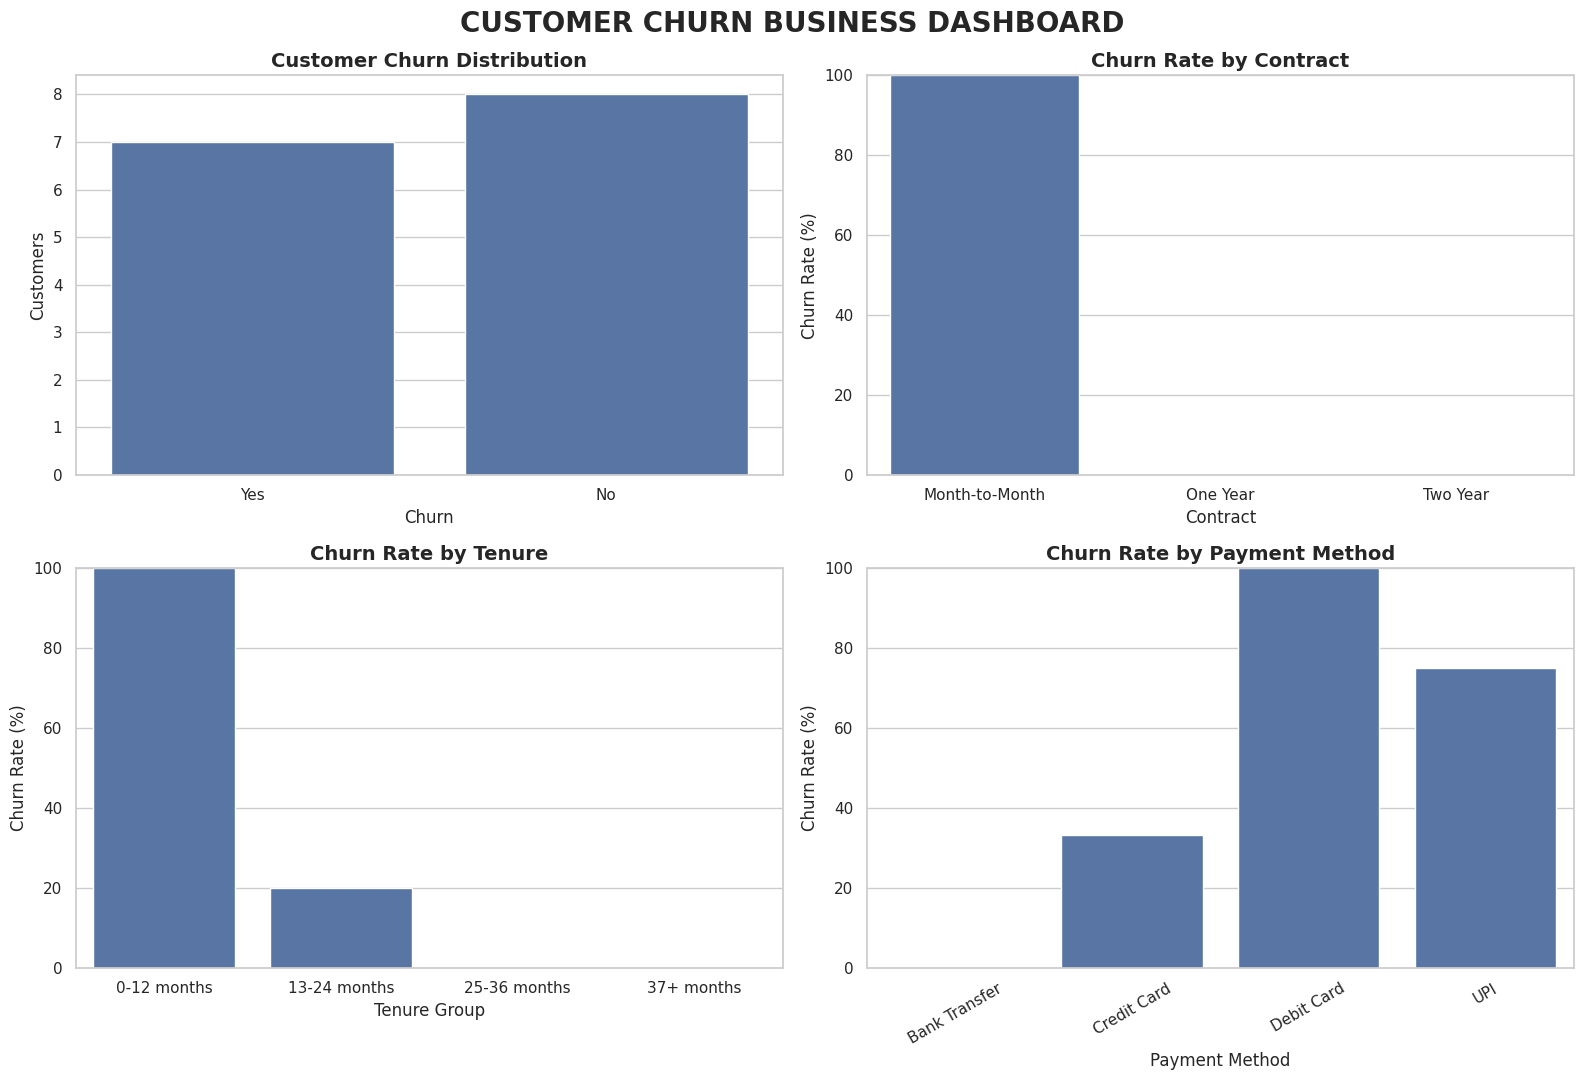

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# -------------------------
# 1. Churn Distribution
# -------------------------
sns.countplot(
    data=df,
    x="Churn",
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Customer Churn Distribution",
    fontsize=14,
    fontweight="bold"
)

axes[0, 0].set_xlabel("Churn")
axes[0, 0].set_ylabel("Customers")


# -------------------------
# 2. Contract Churn
# -------------------------
sns.barplot(
    data=contract_churn,
    x="ContractType",
    y="ChurnRate",
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Churn Rate by Contract",
    fontsize=14,
    fontweight="bold"
)

axes[0, 1].set_xlabel("Contract")
axes[0, 1].set_ylabel("Churn Rate (%)")
axes[0, 1].set_ylim(0, 100)


# -------------------------
# 3. Tenure Churn
# -------------------------
sns.barplot(
    data=tenure_churn,
    x="TenureGroup",
    y="ChurnRate",
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "Churn Rate by Tenure",
    fontsize=14,
    fontweight="bold"
)

axes[1, 0].set_xlabel("Tenure Group")
axes[1, 0].set_ylabel("Churn Rate (%)")
axes[1, 0].set_ylim(0, 100)


# -------------------------
# 4. Payment Churn
# -------------------------
sns.barplot(
    data=payment_churn,
    x="PaymentMethod",
    y="ChurnRate",
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Churn Rate by Payment Method",
    fontsize=14,
    fontweight="bold"
)

axes[1, 1].set_xlabel("Payment Method")
axes[1, 1].set_ylabel("Churn Rate (%)")
axes[1, 1].tick_params(axis="x", rotation=30)
axes[1, 1].set_ylim(0, 100)


plt.suptitle(
    "CUSTOMER CHURN BUSINESS DASHBOARD",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# 19. Business Insights

Based on the exploratory dashboard, the following observations can
be made:

### 1. Overall Churn

The dataset contains both churned and retained customers. The overall
churn rate provides a high-level measure of customer attrition.

### 2. Contract

Churn rates differ across contract types. Contract categories with
higher observed churn may deserve additional investigation and
retention initiatives.

### 3. Tenure

The tenure analysis helps identify whether churn is concentrated
among newer or longer-term customers.

### 4. Payment Method

Different payment methods show different observed churn rates.
The business could investigate whether payment experience or customer
behavior contributes to these differences.

### 5. Revenue Risk

Revenue at Risk connects customer churn to financial impact by measuring
the monthly charges associated with churned customers.

### Important Limitation

This dataset contains a very small number of synthetic records.
Therefore, the patterns identified in this analysis should be treated
as exploratory signals rather than statistically reliable conclusions
about a real customer population.

In [49]:
dashboard_dataset = df.copy()

dashboard_dataset.to_csv(
    "customer_churn_task03_dashboard.csv",
    index=False
)

print("Dashboard dataset successfully exported.")

Dashboard dataset successfully exported.


In [50]:
from google.colab import files

files.download("customer_churn_task03_dashboard.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusion

The customer churn dataset was transformed into a business-oriented
KPI dashboard.

The analysis included:

- Total Customers
- Churned Customers
- Retained Customers
- Churn Rate
- Retention Rate
- Total Monthly Revenue
- Revenue at Risk
- Churn by Contract
- Churn by Tenure
- Churn by Payment Method
- Churn by Subscription Type
- Churn by Support Tickets

The dashboard provides a concise view of customer retention and
financial risk.

The results can be used as the foundation for the next stage of the
project, where customers will be segmented and assigned an
explainable churn-risk score.

### Limitation

The dataset is small and synthetic, so the findings should not be
generalized to a larger customer population without additional data
and statistical validation.

